# Shor 9-Qubit Code — Syndrome Detection & Correction

Full syndrome-based implementation following the [IBM Quantum Foundations of QEC course](https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/correcting-quantum-errors/shor-code).

**What this notebook does:**

1. Encodes a logical qubit across 9 physical qubits
2. Injects an error (X, Z, or Y) on any one qubit
3. Measures 8 syndrome bits via dedicated ancilla qubits — *without* disturbing the data
4. Classically decodes the syndrome → identifies what and where the error is
5. Applies the correction gate(s)
6. Verifies recovery via histogram and state-fidelity
7. **Sweeps all 27 cases** (3 error types × 9 qubits) and reports a full results table

## Theory

### Structure: concatenated repetition codes

The Shor code is built by **concatenating** two 3-qubit repetition codes:

```
Outer code  (phase protection):   1 qubit → 3 block heads
Inner code  (bit protection):     each head → 3 qubits per block

Block 0: q0  q1  q2   ← head q0
Block 1: q3  q4  q5   ← head q3
Block 2: q6  q7  q8   ← head q6
```

Logical codewords:
$$|0\rangle_L = \frac{1}{2\sqrt{2}}(|000\rangle+|111\rangle)^{\otimes 3}, \quad |1\rangle_L = \frac{1}{2\sqrt{2}}(|000\rangle-|111\rangle)^{\otimes 3}$$

### Stabilisers and what they detect

The code has 8 stabiliser generators, each measured by one ancilla qubit:

**Bit-flip (Z-type) stabilisers** — detect X errors:

| Ancilla | Stabiliser | Fires when |
|---------|-----------|------------|
| `ab[0]` | $Z_0 Z_1$ | q0 and q1 disagree |
| `ab[1]` | $Z_1 Z_2$ | q1 and q2 disagree |
| `ab[2]` | $Z_3 Z_4$ | q3 and q4 disagree |
| `ab[3]` | $Z_4 Z_5$ | q4 and q5 disagree |
| `ab[4]` | $Z_6 Z_7$ | q6 and q7 disagree |
| `ab[5]` | $Z_7 Z_8$ | q7 and q8 disagree |

**Phase-flip (X-type) stabilisers** — detect Z errors (measured in Hadamard-rotated basis):

| Ancilla | Stabiliser | Fires when |
|---------|-----------|------------|
| `ap[0]` | $X_0X_1X_2X_3X_4X_5$ | blocks 0 and 1 have different parity (in X-basis) |
| `ap[1]` | $X_3X_4X_5X_6X_7X_8$ | blocks 1 and 2 have different parity (in X-basis) |

**Why X-basis parity detects Z errors:**  
Under $H^{\otimes 3}$, the correct block $(|000\rangle+|111\rangle)/\sqrt{2}$ maps to the four *even-parity* states $\{|000\rangle,|011\rangle,|101\rangle,|110\rangle\}/2$. A Z error flips the sign, so the block maps instead to the four *odd-parity* states. A parity mismatch between adjacent blocks therefore indicates a Z error in one of them.

### Syndrome tables

**Bit-flip syndrome** (per block $k$, bits `syn[2k]` and `syn[2k+1]`):

| `syn[2k]` | `syn[2k+1]` | X error on |
|-----------|-------------|------------|
| 0 | 0 | none |
| 1 | 0 | qubit $3k$ (head) |
| 1 | 1 | qubit $3k+1$ (middle) |
| 0 | 1 | qubit $3k+2$ (tail) |

**Phase-flip syndrome** (`syn[6]` = `ap[0]`, `syn[7]` = `ap[1]`):

| `syn[6]` | `syn[7]` | Z error in |
|----------|----------|------------|
| 0 | 0 | none |
| 1 | 0 | block 0 → correct q0 |
| 1 | 1 | block 1 → correct q3 |
| 0 | 1 | block 2 → correct q6 |

> **Degeneracy:** A Z error on *any* qubit within a block produces the same syndrome (it is equivalent to a Z error on the block head). The syndrome tells you *which block*, not which qubit — but that is sufficient for correction.

**Y = XZ errors** trigger both syndromes simultaneously; the two corrections are independent.

### Qiskit bit-string reversal

Qiskit returns classical registers **big-endian**: `result[0]` = `syn[7]`, `result[-1]` = `syn[0]`. Always reverse before indexing: `syn_bits = raw[::-1]` so that `syn_bits[i]` == `syn[i]`.

## Imports & Setup

In [1]:
import random
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sim = AerSimulator()

## 1 · Encoding

Starting from $|000000000\rangle$, produces $|0\rangle_L$.

The function receives an existing `QuantumCircuit` and data `QuantumRegister` and appends gates **in-place**, so additional registers (ancilla, classical) can be added before or after without conflict.

In [2]:
def shor_encode(qc, q):
    """
    Append Shor encoding gates to qc acting on data register q (9 qubits).

    Step 1 — Outer (phase repetition):
      CX(q0→q3), CX(q0→q6): copy the logical bit to block heads q3, q6.
      At this point q0, q3, q6 are all in the same Z-basis state.

    Step 2 — Hadamard on block heads:
      H(q0), H(q3), H(q6): rotate each head from |0>/|1> to |+>/|->.
      This enters the phase-protected subspace for the outer code.

    Step 3 — Inner (bit repetition per block):
      CX(head→mid), CX(head→tail) for each block:
      Entangles each block into (|000>+|111>)/sqrt(2) or (|000>-|111>)/sqrt(2).
    """
    # ── Outer: spread logical bit to block heads ─────────────────
    qc.cx(q[0], q[3])
    qc.cx(q[0], q[6])

    # ── Hadamard: rotate heads to X-basis ────────────────────────
    qc.h(q[0]); qc.h(q[3]); qc.h(q[6])

    # ── Inner: bit-flip repetition within each block ─────────────
    for i in [0, 3, 6]:
        qc.cx(q[i], q[i+1])   # head → middle
        qc.cx(q[i], q[i+2])   # head → tail

## 2 · Syndrome Measurement

This is the critical step that separates true QEC from the cheat-correct approach.

**17 qubits total:** 9 data (`q`) + 6 bit-ancilla (`ab`) + 2 phase-ancilla (`ap`).  
**8 syndrome bits:** stored in classical register `syn`.

The data qubits are **never measured** — only the ancilla are. Because the ancilla measurement is deterministic (eigenvalue ±1, not a random collapse), the data stays in its encoded state throughout.

**Proof of non-destructiveness for bit syndrome:**  
For any codeword, `CX(data[a], anc)` then `CX(data[b], anc)` gives `anc = data[a] ⊕ data[b]`. In `(|000⟩+|111⟩)/√2`, qubits `a` and `b` are always equal in every term → `anc = 0` always. In `(|100⟩+|011⟩)/√2` (X error on head), qubits 0 and 1 are always opposite → `anc = 1` always. The ancilla-data state is **separable** before measurement; measuring the ancilla cannot disturb data.

In [3]:
def measure_syndrome(qc, q):
    """
    Append 8 ancilla qubits and syndrome classical register to qc.
    Performs non-destructive stabiliser measurement on data register q.

    Registers added (in order):
      ab  : QuantumRegister(6) — bit-flip ancilla
      ap  : QuantumRegister(2) — phase-flip ancilla
      syn : ClassicalRegister(8) — syndrome output bits

    Syndrome bit layout (after [::-1] reversal of Qiskit's big-endian string):
      syn[0]: Z0Z1   syn[1]: Z1Z2   (block 0)
      syn[2]: Z3Z4   syn[3]: Z4Z5   (block 1)
      syn[4]: Z6Z7   syn[5]: Z7Z8   (block 2)
      syn[6]: X0X1X2X3X4X5          (blocks 0 & 1 phase parity)
      syn[7]: X3X4X5X6X7X8          (blocks 1 & 2 phase parity)
    """
    ab  = QuantumRegister(6, 'ab')
    ap  = QuantumRegister(2, 'ap')
    syn = ClassicalRegister(8, 'syn')
    qc.add_register(ab); qc.add_register(ap); qc.add_register(syn)

    # ── Z-type stabilisers: bit-flip syndrome ────────────────────
    # Pattern: CX(q_a, anc), CX(q_b, anc)  →  anc = q_a ⊕ q_b
    # Measures parity of each neighbouring pair within a block.
    for k, i in enumerate([0, 3, 6]):      # block index k, head qubit i
        qc.cx(q[i],   ab[2*k])             # ─┐ pair (i, i+1) → syn[2k]
        qc.cx(q[i+1], ab[2*k])             # ─┘
        qc.cx(q[i+1], ab[2*k+1])           # ─┐ pair (i+1, i+2) → syn[2k+1]
        qc.cx(q[i+2], ab[2*k+1])           # ─┘

    for i in range(6):
        qc.measure(ab[i], syn[i])           # measure all bit-flip ancilla

    # ── X-type stabilisers: phase-flip syndrome ───────────────────
    # Apply H to all data: maps X-basis eigenvalues to Z-basis.
    # Correct block  (|000>+|111>)/√2  →  even-parity computational states
    # Z-error block  (|000>-|111>)/√2  →  odd-parity computational states
    # Ancilla accumulates XOR of all qubits in two adjacent blocks.
    qc.barrier()
    for i in range(9):
        qc.h(q[i])                          # rotate data to X-basis

    # ap[0]: parity(block 0) ⊕ parity(block 1)  →  syn[6]
    for i in [0, 1, 2, 3, 4, 5]:
        qc.cx(q[i], ap[0])
    qc.measure(ap[0], syn[6])

    # ap[1]: parity(block 1) ⊕ parity(block 2)  →  syn[7]
    for i in [3, 4, 5, 6, 7, 8]:
        qc.cx(q[i], ap[1])
    qc.measure(ap[1], syn[7])

    for i in range(9):
        qc.h(q[i])                          # rotate data back to Z-basis

    return qc

## 3 · Classical Syndrome Decoder

`decode_syndrome(syn_bits)` maps the 8-bit syndrome string to correction operations. This is pure classical logic — no quantum gates involved.

The decoder implements the syndrome tables from the theory section. It returns:
- `bit_corr`: list of qubit indices needing an **X gate** (bit-flip correction)
- `phase_corr`: list of qubit indices needing a **Z gate** (phase-flip correction)
- `description`: human-readable diagnosis string

In [4]:
def decode_syndrome(syn_bits):
    """
    Decode 8-bit syndrome string into correction operations.

    Args:
        syn_bits : str of length 8, AFTER [::-1] reversal.
                   syn_bits[i] corresponds to syn register bit i.

    Returns:
        bit_corr   : list of qubit indices for X-gate correction
        phase_corr : list of qubit indices for Z-gate correction
        desc       : human-readable diagnosis string
    """
    # ── Bit-flip (X error) correction ────────────────────────────
    # Process each block independently using its two syndrome bits.
    bit_corr = []
    desc_parts = []

    BIT_TABLE = {
        '00': None,   # no X error in this block
        '10': 0,      # X on head   (qubit 3k)
        '11': 1,      # X on middle (qubit 3k+1)
        '01': 2,      # X on tail   (qubit 3k+2)
    }

    for k in range(3):                         # k = block index 0,1,2
        s = syn_bits[2*k : 2*k+2]             # two syndrome bits for block k
        offset = BIT_TABLE.get(s)             # position within block (0,1,2) or None
        if offset is not None:
            qubit = 3*k + offset
            bit_corr.append(qubit)
            desc_parts.append(f'X on q{qubit} (blk{k})')

    # ── Phase-flip (Z error) correction ──────────────────────────
    # Two syndrome bits identify which block has a Z error.
    # Correction: Z on the block HEAD (any qubit in the block works;
    # the head is conventional).
    phase_corr = []

    PHASE_TABLE = {
        '00': None,   # no Z error
        '10': 0,      # Z in block 0 → correct q0
        '11': 3,      # Z in block 1 → correct q3
        '01': 6,      # Z in block 2 → correct q6
    }

    p = syn_bits[6:8]                          # bits syn[6] and syn[7]
    head = PHASE_TABLE.get(p)
    if head is not None:
        phase_corr.append(head)
        block = head // 3
        desc_parts.append(f'Z in blk{block} → correct q{head}')

    if not desc_parts:
        desc_parts = ['no error detected']

    return bit_corr, phase_corr, ' | '.join(desc_parts)


def apply_corrections(qc, q, bit_corr, phase_corr):
    """
    Apply X gates for bit-flip corrections and Z gates for phase-flip corrections.
    X^2 = Z^2 = I, so each gate undoes its corresponding error exactly.
    """
    for qi in bit_corr:
        qc.x(q[qi])       # X · X = I  (undoes bit-flip)
    for qi in phase_corr:
        qc.z(q[qi])       # Z · Z = I  (undoes phase-flip)

## 4 · Full Pipeline

Two helper functions:

- `extract_syndrome(err_qubit, err_type)` — builds and simulates the syndrome circuit, returns the raw syndrome bits and decoded corrections.
- `run_shor(err_qubit, err_type, shots)` — builds the correction circuit (encode → inject → correct → measure q0), runs it, and computes state fidelity.

The two circuits are **independent**: the syndrome circuit is used only to determine the correction; the correction circuit rebuilds the state from scratch. This is the standard simulation strategy.

In [11]:
def extract_syndrome(err_qubit, err_type):
    """
    Build and simulate the syndrome circuit. Return decoded syndrome info.

    Returns:
        syn_bits   : 8-char string, syn_bits[i] = syn[i]
        bit_corr   : list of qubit indices for X correction
        phase_corr : list of qubit indices for Z correction
        desc       : human-readable diagnosis
    """
    q   = QuantumRegister(9, 'q')
    qc  = QuantumCircuit(q)
    shor_encode(qc, q)

    # Inject error
    if err_type in ('X', 'Y'):  qc.x(q[err_qubit])
    if err_type in ('Z', 'Y'):  qc.z(q[err_qubit])

    measure_syndrome(qc, q)     # appends ancilla + syn register

    # Noiseless simulation: shots=1 is sufficient (syndrome is deterministic)
    result   = sim.run(transpile(qc, sim), shots=1).result()
    raw      = list(result.get_counts().keys())[0]
    syn_bits = raw[::-1]        # fix Qiskit big-endian ordering

    bit_corr, phase_corr, desc = decode_syndrome(syn_bits)
    return syn_bits, bit_corr, phase_corr, desc


def run_shor(err_qubit, err_type, shots=1024):
    """
    Full pipeline: encode → inject → syndrome decode → correct → measure q0.

    Returns:
        counts     : measurement counts dict for q0
        fidelity   : |<ψ_corrected|ψ_ideal>|^2  (1.0 = perfect correction)
        syn_bits   : 8-char syndrome string
        bit_corr   : X corrections applied
        phase_corr : Z corrections applied
        desc       : diagnosis string
    """
    # ── Step 1: Extract syndrome (separate circuit) ──────────────
    syn_bits, bit_corr, phase_corr, desc = extract_syndrome(err_qubit, err_type)

    # ── Step 2: Build correction circuit ─────────────────────────
    q  = QuantumRegister(9, 'q')
    c0 = ClassicalRegister(1, 'c')     # only measure logical qubit q0
    qc = QuantumCircuit(q, c0)

    shor_encode(qc, q)

    # Re-inject the same error
    if err_type in ('X', 'Y'):  qc.x(q[err_qubit])
    if err_type in ('Z', 'Y'):  qc.z(q[err_qubit])

    qc.barrier(q)
    apply_corrections(qc, q, bit_corr, phase_corr)
    qc.barrier(q)

    # ── Step 3: Statevector fidelity (no measurement yet) ────────
    # Compare corrected state with clean |0>_L
    qc_ref       = QuantumCircuit(QuantumRegister(9, 'q'))
    shor_encode(qc_ref, qc_ref.qregs[0])
    sv_ref       = Statevector(qc_ref)
    sv_corr      = Statevector(qc)   # statevector of 9 data qubits after correction
    fidelity     = abs(sv_ref.inner(sv_corr)) ** 2

    # ── Step 4: Histogram measurement ────────────────────────────
    qc.measure(q[0], c0[0])
    result = sim.run(transpile(qc, sim), shots=shots).result()
    counts = result.get_counts()

    return counts, fidelity, syn_bits, bit_corr, phase_corr, desc

---
## Part A — Step-by-Step Demo

We walk through the full pipeline for the reference case: **Y error (X+Z) on qubit 0**. Each step is shown separately so the syndrome-decode-correct flow is visible.

### A-1 · Encoding circuit

Encoding circuit (9 data qubits, starting from |000000000>):


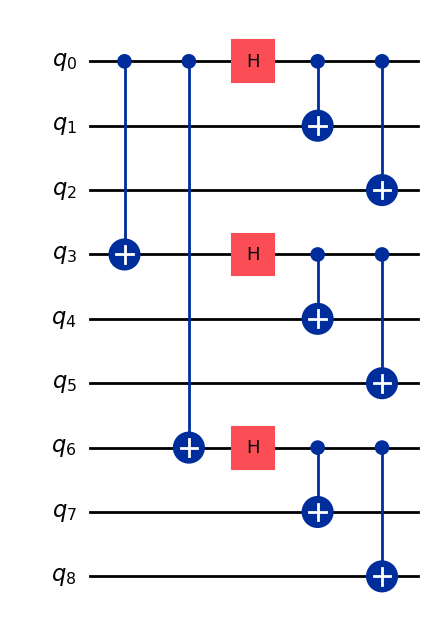

In [12]:
q_demo = QuantumRegister(9, 'q')
qc_demo = QuantumCircuit(q_demo)
shor_encode(qc_demo, q_demo)

print("Encoding circuit (9 data qubits, starting from |000000000>):")
qc_demo.draw('mpl', fold=-1)

### A-2 · Syndrome circuit (with Y error on q0)

The circuit appends 8 ancilla and runs the stabiliser measurements. The data qubits q0–q8 are **never measured** here — only `ab[0..5]` and `ap[0,1]` are.

Circuit: 17 qubits (9 data + 6 bit-ancilla + 2 phase-ancilla), 8 classical bits


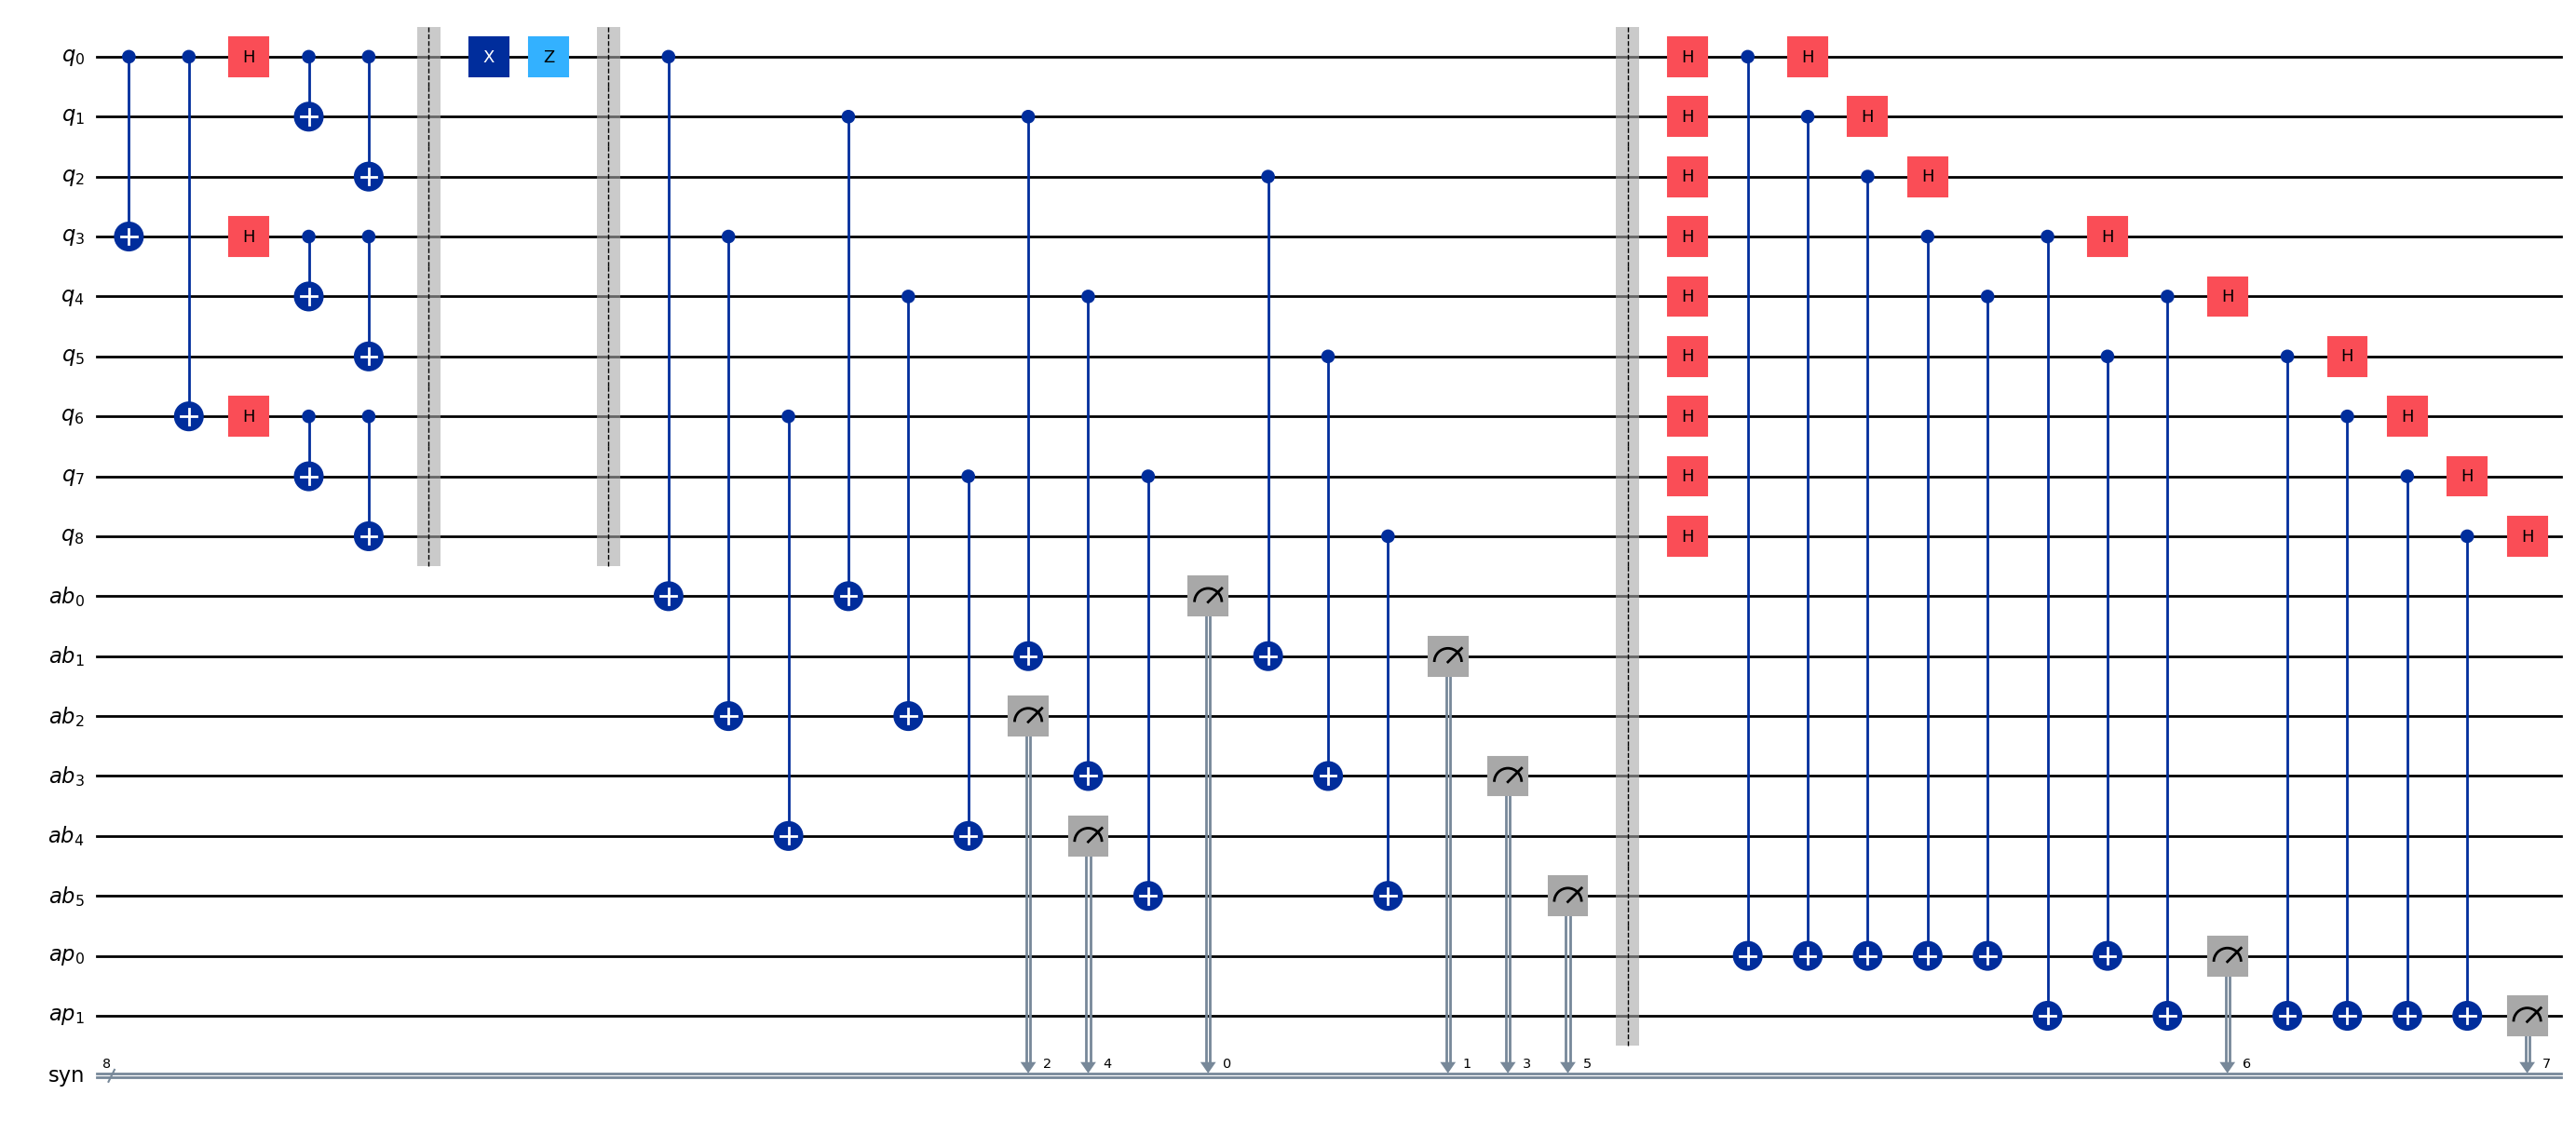

In [13]:
q_s = QuantumRegister(9, 'q')
qc_s = QuantumCircuit(q_s)
shor_encode(qc_s, q_s)
qc_s.barrier(q_s)

# Y error = X then Z on qubit 0
qc_s.x(q_s[0])
qc_s.z(q_s[0])
qc_s.barrier(q_s)

measure_syndrome(qc_s, q_s)

print(f"Circuit: {qc_s.num_qubits} qubits "
      f"(9 data + 6 bit-ancilla + 2 phase-ancilla), {len(qc_s.clbits)} classical bits")
qc_s.draw('mpl', fold=-1)

### A-3 · Syndrome simulation and classical decoding

In [14]:
# Simulate syndrome circuit
result_s = sim.run(transpile(qc_s, sim), shots=1).result()
raw_s    = list(result_s.get_counts().keys())[0]
syn_s    = raw_s[::-1]   # fix Qiskit big-endian

# Decode
bit_c, phase_c, diag = decode_syndrome(syn_s)

print(f"Raw bitstring (Qiskit big-endian, syn[7]..syn[0]) : {raw_s}")
print(f"Corrected ordering   (syn[0]..syn[7])             : {syn_s}")
print()
print("Syndrome breakdown:")
print(f"  Block 0 bit-syndrome  syn[0]syn[1] = {syn_s[0]}{syn_s[1]}")
print(f"  Block 1 bit-syndrome  syn[2]syn[3] = {syn_s[2]}{syn_s[3]}")
print(f"  Block 2 bit-syndrome  syn[4]syn[5] = {syn_s[4]}{syn_s[5]}")
print(f"  Phase syndrome        syn[6]syn[7] = {syn_s[6]}{syn_s[7]}")
print()
print(f"Classical decoder output:")
print(f"  Diagnosis       : {diag}")
print(f"  X corrections   : qubits {bit_c}")
print(f"  Z corrections   : qubits {phase_c}")

Raw bitstring (Qiskit big-endian, syn[7]..syn[0]) : 01000001
Corrected ordering   (syn[0]..syn[7])             : 10000010

Syndrome breakdown:
  Block 0 bit-syndrome  syn[0]syn[1] = 10
  Block 1 bit-syndrome  syn[2]syn[3] = 00
  Block 2 bit-syndrome  syn[4]syn[5] = 00
  Phase syndrome        syn[6]syn[7] = 10

Classical decoder output:
  Diagnosis       : X on q0 (blk0) | Z in blk0 → correct q0
  X corrections   : qubits [0]
  Z corrections   : qubits [0]


### A-4 · Correction circuit and verification

A fresh circuit encodes the qubit, injects the same error, applies the decoder's corrections, then measures $q_0$.

Measurement counts for q0 : {'1': 516, '0': 508}
P('0') = 50.8%
State fidelity with |0>_L : 1.000000
Result: ✅ Corrected


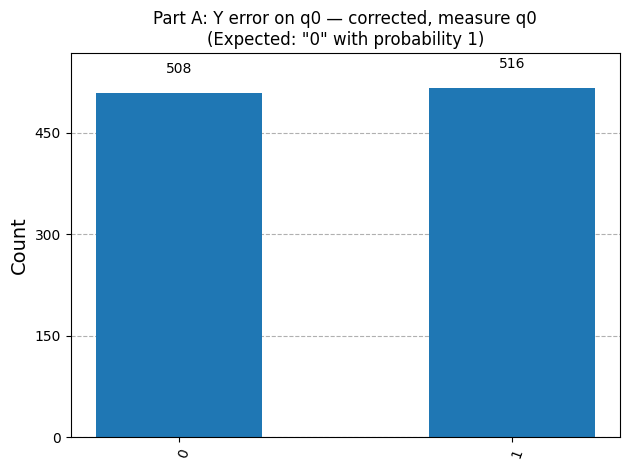

In [15]:
counts_demo, fid_demo, *_ = run_shor(err_qubit=0, err_type='Y', shots=1024)

print(f"Measurement counts for q0 : {counts_demo}")
print(f"P('0') = {counts_demo.get('0',0)/10:.1f}%")
print(f"State fidelity with |0>_L : {fid_demo:.6f}")
status = '✅ Corrected' if fid_demo > 0.999 else '❌ Failed'
print(f"Result: {status}")

plot_histogram(counts_demo,
               title='Part A: Y error on q0 — corrected, measure q0\n'
               '(Expected: "0" with probability 1)')

---
## Part B — All 27 Cases: Every Error Type × Every Qubit

Sweep **X, Z, Y** errors on every qubit **q0–q8**. For each case we report:
- The 8-bit syndrome string (formatted as `bit:XXXXXX | phase:XX`)
- The classical decoder's diagnosis
- State fidelity with $|0\rangle_L$ after correction
- Pass / Fail

**Expected syndrome patterns:**

| Error | Qubit | syn[0:6] (bit) | syn[6:8] (phase) |
|-------|-------|---------------|------------------|
| X | q0,q3,q6 | 10 / 00 / 00 or variants | 00 |
| Z | any in blk0 | 000000 | 10 |
| Z | any in blk1 | 000000 | 11 |
| Z | any in blk2 | 000000 | 01 |
| Y | qk | both X and Z patterns | combined |

Run all 27 cases (takes ~30 s):

In [16]:
ERROR_TYPES = ['X', 'Z', 'Y']
QUBITS      = list(range(9))
BLOCK       = lambda q: q // 3
ROLE        = lambda q: ['head','mid ','tail'][q % 3]

results = {}   # (qubit, etype) → dict

for etype in ERROR_TYPES:
    for qubit in QUBITS:
        counts, fid, syn, bc, pc, diag = run_shor(qubit, etype, shots=512)
        p0 = counts.get('0', 0) / 512 * 100
        results[(qubit, etype)] = dict(
            syn=syn, bit_corr=bc, phase_corr=pc,
            diag=diag, fidelity=fid, p0=p0
        )

print("Sweep complete.")

Sweep complete.


### Results table

In [17]:
print(f"{'Err':3} {'Qubit':5} {'Blk':3} {'Role':4}  "
      f"{'Bit syn (6)':12} {'Ph syn (2)':10} "
      f"{'Decoder diagnosis':35} {'Fid':6} {'Status'}")
print('─' * 110)

all_pass = True
for etype in ERROR_TYPES:
    for q in QUBITS:
        r = results[(q, etype)]
        bit_s   = r['syn'][0:6]
        phase_s = r['syn'][6:8]
        fid     = r['fidelity']
        ok      = fid > 0.999
        status  = '✅' if ok else '❌'
        if not ok:
            all_pass = False
        print(f"{etype:3} {'q'+str(q):5} {'B'+str(BLOCK(q)):3} {ROLE(q):4}  "
              f"{bit_s:12} {phase_s:10} "
              f"{r['diag']:35} {fid:.4f} {status}")
    print()

print('─' * 110)
print(f"All 27 cases passed: {'✅ YES' if all_pass else '❌ NO'}")

Err Qubit Blk Role  Bit syn (6)  Ph syn (2) Decoder diagnosis                   Fid    Status
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
X   q0    B0  head  100000       00         X on q0 (blk0)                      1.0000 ✅
X   q1    B0  mid   110000       00         X on q1 (blk0)                      1.0000 ✅
X   q2    B0  tail  010000       00         X on q2 (blk0)                      1.0000 ✅
X   q3    B1  head  001000       00         X on q3 (blk1)                      1.0000 ✅
X   q4    B1  mid   001100       00         X on q4 (blk1)                      1.0000 ✅
X   q5    B1  tail  000100       00         X on q5 (blk1)                      1.0000 ✅
X   q6    B2  head  000010       00         X on q6 (blk2)                      1.0000 ✅
X   q7    B2  mid   000011       00         X on q7 (blk2)                      1.0000 ✅
X   q8    B2  tail  000001       00         X on q8 (blk2)                      1.0

### Syndrome map visualisation

For each error type and qubit, plot the 8 syndrome bits as a colour map. This makes it easy to see the regular structure: the bit syndrome shifts within blocks for X errors, and the phase syndrome is block-dependent for Z errors.

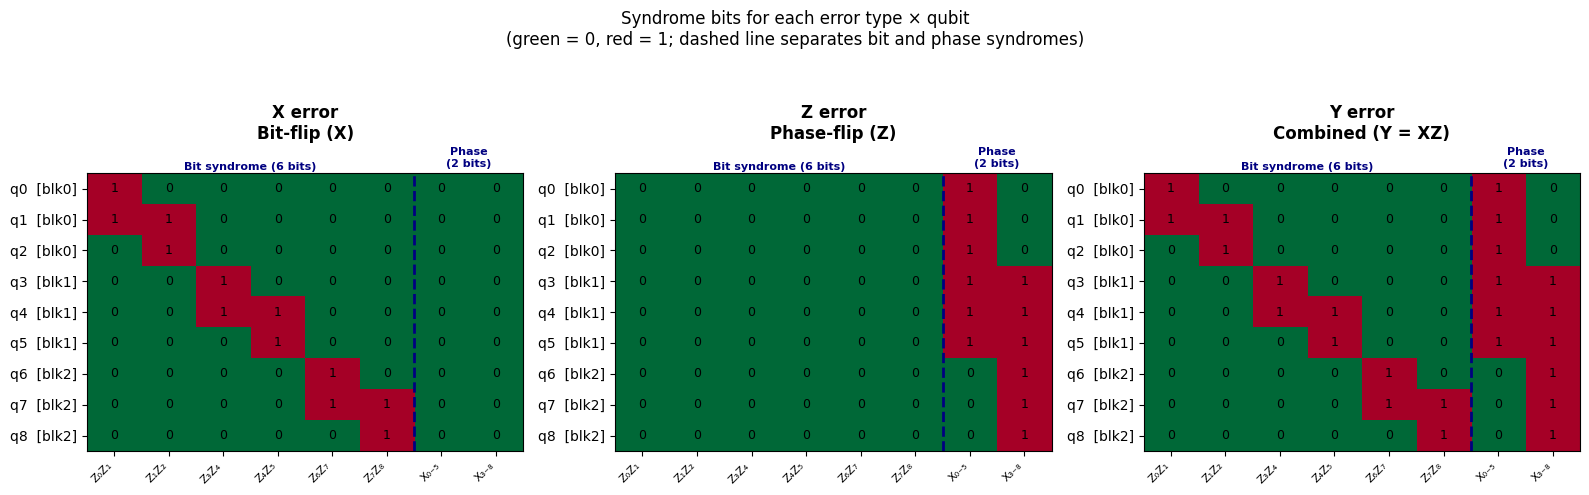

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming ERROR_TYPES, QUBITS, and results are defined elsewhere
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
etype_names = {'X': 'Bit-flip (X)', 'Z': 'Phase-flip (Z)', 'Y': 'Combined (Y = XZ)'}

for ax, etype in zip(axes, ERROR_TYPES):
    matrix = np.zeros((9, 8), dtype=int)
    for q in QUBITS:
        s = results[(q, etype)]['syn']
        matrix[q] = [int(b) for b in s]

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
    
    # Formatting ticks
    ax.set_xticks(range(8))
    ax.set_xticklabels(
        ['Z₀Z₁','Z₁Z₂','Z₃Z₄','Z₄Z₅','Z₆Z₇','Z₇Z₈',
         'X₀₋₅','X₃₋₈'], fontsize=8, rotation=45, ha='right')
    ax.set_yticks(range(9))
    ax.set_yticklabels([f'q{i}  [blk{i//3}]' for i in range(9)])
    
    # FIX 1: Increased title padding to prevent overlap with the syndrome labels
    ax.set_title(f'{etype} error\n{etype_names[etype]}', fontweight='bold', pad=25)

    # Annotate each cell
    for r in range(9):
        for c in range(8):
            ax.text(c, r, str(matrix[r, c]), ha='center', va='center',
                    fontsize=9, color='black')

    # Vertical separator between bit and phase syndromes
    ax.axvline(5.5, color='navy', linewidth=2, linestyle='--')
    
    # FIX 2: Adjusted y-position (-0.6 instead of -0.8) to sit closer to the grid 
    # and further from the title
    ax.text(2.5, -0.6, 'Bit syndrome (6 bits)', ha='center', fontsize=8, color='navy', fontweight='bold')
    ax.text(6.5, -1.0, 'Phase\n(2 bits)', ha='center', va='center', fontsize=8, color='navy', fontweight='bold')

# FIX 3: Adjusted suptitle and rect in tight_layout to ensure nothing gets cut off
plt.suptitle('Syndrome bits for each error type × qubit\n'
             '(green = 0, red = 1; dashed line separates bit and phase syndromes)',
             fontsize=12, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.93]) # Leaves room at the top for the suptitle
plt.show()

### Fidelity summary

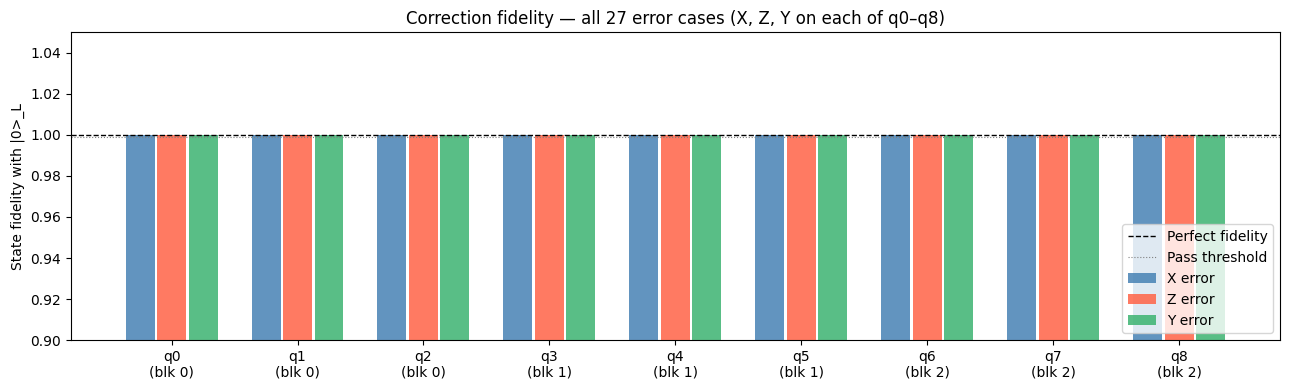

In [23]:
fig, ax = plt.subplots(figsize=(13, 4))

colors  = {'X': 'steelblue', 'Z': 'tomato', 'Y': 'mediumseagreen'}
offsets = {'X': -0.25, 'Z': 0.0, 'Y': 0.25}

for etype in ERROR_TYPES:
    xs  = [q + offsets[etype] for q in QUBITS]
    fids = [results[(q, etype)]['fidelity'] for q in QUBITS]
    ax.bar(xs, fids, width=0.23, color=colors[etype],
           label=f'{etype} error', alpha=0.85)

ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='Perfect fidelity')
ax.axhline(0.999, color='gray', linewidth=0.8, linestyle=':', label='Pass threshold')
ax.set_xticks(QUBITS)
ax.set_xticklabels([f'q{i}\n(blk {i//3})' for i in QUBITS])
ax.set_ylim(0.9, 1.05)
ax.set_ylabel('State fidelity with |0>_L')
ax.set_title('Correction fidelity — all 27 error cases (X, Z, Y on each of q0–q8)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Summary

### What this notebook demonstrated

| Step | Action | Quantum / Classical |
|------|--------|--------------------|
| 1 | Encode 1 logical qubit into 9 physical qubits | Quantum |
| 2 | Inject single-qubit error (X, Z, or Y) | Quantum |
| 3 | Measure 8 syndrome bits via 8 ancilla qubits | Quantum (non-destructive) |
| 4 | Decode syndrome: identify error type and location | **Classical** |
| 5 | Apply correction gate(s) | Quantum |
| 6 | Verify recovery (histogram + fidelity) | Classical |

### Key design points from IBM's course

**Bit-flip correction (inner code):** Each block is treated independently as a 3-bit repetition code. The pair of syndrome bits per block locates the X error exactly.

**Phase-flip correction (outer code):** A Z error on *any* qubit in a block is equivalent to a Z error on the block head — the syndrome only identifies the block, not the qubit. This is **degeneracy**: we correct without fully identifying the error. We apply Z to the block head; any qubit in the block works equally well.

**Y errors:** Y = iXZ triggers both syndromes. Since the bit and phase corrections commute (they act on orthogonal subspaces), they can be applied in any order.

**Non-destructive measurement:** The ancilla are initialised to $|0\rangle$ and accumulate parity via CX gates. For every valid codeword ± one error, the ancilla-data state is **separable** before measurement, so measuring the ancilla gives a deterministic outcome and leaves the data intact.

**Break-even error rate (from IBM):** The code provides an advantage over unprotected storage only when the per-qubit error probability $p < 0.0323$ (≈3.2%). Above this, using the code makes things worse due to the overhead of 9 physical qubits.